## Групповой проект №2. DE: Scraping & API

**Участники проекта:**

Белоусов Дмитрий Анатольевич (ББИ233)

Морозова Мария Михайловна (ББИ233)

Суворов Александр Германович (ББИ233)


Данный проект фокусируется на анализе платформ по поиску, подбору и агрегации ваканский - HeadHunter и SuperJob.

Для работы были выбраны вакансии, связанные с анализом данных и бизнеса.

In [157]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.io as pio
import seaborn as sns
import ast
from collections import Counter
from geopy.geocoders import Nominatim
import re

###**1. Проверка данных на наличие дубликатов**

In [48]:
hh = pd.read_csv('hh.csv', header='infer', sep=',', index_col=0)
hh_dubl_sum = hh.duplicated().sum()
hh_dubl = hh[hh.duplicated()]
hh_dubl
hh_dubl_sum
hh.drop_duplicates()

,id,url,name,salary,description,skills,company,address,area,experience,employment,schedule,working_hours,work_format,published_at,archived,source
0,131879499,https://hh.ru/vacancy/131879499,Стажер аналитик-разработчик в Яндекс,NaN,Приглашаем начинающих аналитиков работать с бо...,"['Python', 'SQL', 'Pandas', 'Git']",Яндекс,"Москва , Парк культуры , улица Льва Толстого, 16",Москва,не требуется,Полная занятость Стажировка,свободный,NaN,на месте работодателя,2026-04-06T15:30:24.020+03:00,False,hh
1,131881194,https://hh.ru/vacancy/131881194,Стажёр в отдел развития инструментов управлени...,NaN,Обязанности:\nПоддержка и развитие инструменто...,"['Python', 'SQL', 'Spark', 'Git']",Альфа-Банк. Работа без опыта,"Москва, Москва",Москва,не требуется,Полная занятость,5/2,NaN,гибрид,2026-04-06T16:03:30.675+03:00,False,hh
2,131961234,https://hh.ru/vacancy/131961234,Стажер (количественные исследования),NaN,Компания «Михайлов и Партнёры. Аналитика»\nзан...,"['MS Excel', 'Работа с большим объемом информа...",Михайлов и Партнёры,"Москва , Динамо , Петровский парк , Ленинградс...",Москва,не требуется,Частичная занятость Стажировка,5/2,4,на месте работодателя,2026-04-08T16:18:53.219+03:00,False,hh
3,131685088,https://hh.ru/vacancy/131685088,Бизнес-администратор SQL,NaN,Чем предстоит заниматься\n:\nРазработка и опти...,['SQL'],Сентинел Кредит Менеджмент,"Москва , Студенческая , набережная Тараса Шевч...",Москва,не требуется,Полная занятость,5/2,8,на месте работодателя,2026-04-06T07:38:28.983+03:00,False,hh
4,131927548,https://hh.ru/vacancy/131927548,Аналитик по продажам и управлению данными,NaN,Обязанности:\nОбеспечивать наличие качественно...,"['Анализ рынка', 'MS Excel', 'Power Query', 'P...",Bonduelle,"Москва , Красносельская , Верхняя Красносельск...",Москва,1–3 года,Полная занятость,5/2,8,гибрид,2026-04-07T17:33:02.176+03:00,False,hh
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10280,131949560,https://hh.ru/vacancy/131949560,Категорийный менеджер ТМ FUNDAY (маркетплейсы),NaN,Вам предстоит:\nМониторинг конкурентов с целью...,"['Excel', 'Git']",OSTIN. Офис и мастерская,"Москва , Аэропорт , Гражданская , Кочновский п...",Москва,1–3 года,Полная занятость,5/2,8,гибрид,2026-04-08T12:21:57.365+03:00,False,hh
10287,131982166,https://hh.ru/vacancy/131982166,Финансовый менеджер (франчайзинг),NaN,Обязанности:\nМетодологическая поддержка колле...,"['Excel', 'Git']",Пятёрочка. Офисные сотрудники,"Москва, Москва",Москва,1–3 года,Полная занятость,5/2,8,гибрид,2026-04-09T11:24:00.303+03:00,False,hh
10288,131986678,https://hh.ru/vacancy/131986678,Старший аналитик по повышению эффективности би...,NaN,Excellence Expert\n– российская компания экспе...,"['Excel', 'Git']",Excellence Expert,"Москва, Москва",Москва,3–6 лет,Полная занятость,5/2,8,на месте работодателя,2026-04-09T12:40:15.659+03:00,False,hh
10289,131990661,https://hh.ru/vacancy/131990661,Python Backend Developer,NaN,Мы — «Национальная Служба Списания Долгов»\n— ...,"['Python', 'PostgreSQL', 'FastAPI']",НССД,"Москва , Курская , Курская , Курская , Чкаловс...",Москва,3–6 лет,Полная занятость,5/2,8,на месте работодателя,2026-04-09T13:57:27.142+03:00,False,hh


**Вывод**: в данных есть дубликаты, что может быть связано с возобновлением поиска сотрудников на вакансию и ее повторным открытием и последующим закрытием на платформе.

Количество строк-дубликатов на платформе HH.ru - 2383 штуки.

In [50]:
superjob = pd.read_csv('superjob.csv', header='infer', sep=',', index_col=0)
superjob = pd.read_csv('superjob.csv', header='infer', sep=',', index_col=0)
superjob
superjob_dubl_sum = superjob.duplicated().sum()
superjob_dubl = superjob[superjob.duplicated()]
superjob

,id,url,name,salary,salary_from,salary_to,currency,description,skills,company,...,experience,employment,schedule,working_hours,work_format,published_at,catalogue_ids,catalogue_titles,source,query
0,51646140,https://www.superjob.ru/vakansii/stazhjor-anal...,Стажёр аналитик продаж в департамент розничных...,NaN,NaN,NaN,rub,"Описание направления\n\nТы будешь собирать, ст...",['Excel'],Альфа-Банк: Старт карьеры,...,Без опыта,Полный рабочий день,Полный рабочий день,NaN,Не имеет значения,2026-04-07T17:45:04,"[33, 438]","['IT, Интернет, связь, телеком', 'Продажи']",superjob,аналитик данных
1,51754779,https://www.superjob.ru/vakansii/sistemnyj-ana...,Системный аналитик,NaN,NaN,NaN,rub,Контур — экосистема для бизнеса. Наши сервисы ...,[],Контур,...,От 3 лет,Полный рабочий день,Полный рабочий день,NaN,Не имеет значения,2026-04-07T18:50:03,[33],"['IT, Интернет, связь, телеком']",superjob,аналитик данных
2,51760920,https://www.superjob.ru/vakansii/prodakt-mened...,Продакт-менеджер,NaN,NaN,NaN,rub,Мы развиваем продуктовые направления на стыке ...,[],КРОК,...,От 3 лет,Полный рабочий день,Полный рабочий день,NaN,Не имеет значения,2026-04-08T13:35:21,[33],"['IT, Интернет, связь, телеком']",superjob,аналитик данных
3,51182014,https://www.superjob.ru/vakansii/veduschij-kon...,Ведущий консультант отдела аналитики и искусст...,NaN,NaN,NaN,rub,Должность предполагает участие в развитии анал...,"['Python', 'SQL', 'Pandas', 'Excel']",Социальный фонд России,...,От 3 лет,Полный рабочий день,Полный рабочий день,NaN,Не имеет значения,2026-04-07T15:41:28,[33],"['IT, Интернет, связь, телеком']",superjob,аналитик данных
4,51699614,https://www.superjob.ru/vakansii/starshij-kopi...,Старший копирайтер по продуктам,NaN,NaN,NaN,rub,О вакансии\n\nВ качестве писателя вы станете ч...,['A/B тесты'],Duolingo,...,От 1 года,Полный рабочий день,Полный рабочий день,NaN,Не имеет значения,2026-04-08T11:35:42,[234],"['Маркетинг, реклама, PR']",superjob,аналитик данных
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,51778870,https://spb.superjob.ru/vakansii/specialist-ot...,Специалист отдела аналитического обеспечения и...,от 100000 rub,100000.0,NaN,rub,Обязанности:\n• Обеспечение информационной и т...,[],"СПб ГКУ ""Городской центр управления парковками...",...,От 1 года,Полный рабочий день,Полный рабочий день,NaN,Не имеет значения,2026-04-07T16:25:00,[33],"['IT, Интернет, связь, телеком']",superjob,аналитик
80,51778885,https://spb.superjob.ru/vakansii/glavnyj-speci...,Главный специалист Отдела аналитического обесп...,от 110000 rub,110000.0,NaN,rub,Обязанности:\n• \nАдминистрирование сетевой ин...,[],"СПб ГКУ ""Городской центр управления парковками...",...,От 3 лет,Полный рабочий день,Полный рабочий день,NaN,Не имеет значения,2026-04-07T16:35:00,"[11, 234]","['Бухгалтерия, финансы, аудит', 'Маркетинг, ре...",superjob,аналитик
81,51673581,https://spb.superjob.ru/vakansii/nachalnik-kom...,Начальник коммерческо-аналитического отдела,от 60000 до 65000 rub,60000.0,65000.0,rub,"Обязанности:\n• Сбор, обработка и подготовка п...",[],СПбГЭУ,...,От 1 года,Полный рабочий день,Полный рабочий день,NaN,Не имеет значения,2026-04-07T15:14:00,[478],['Топ-персонал'],superjob,аналитик
82,51682983,https://spb.superjob.ru/vakansii/specialist-ot...,Специалист Отдела анализа рынков Контрактной с...,от 75000 до 75000 rub,75000.0,75000.0,rub,Обязанности: \n1. Поиск потенциальных поставщи...,[],ФГБОУ ВО Санкт-Петербургский государственный у...,...,Без опыта,Полный рабочий день,Полный рабочий день,NaN,Не имеет значения,2026-04-07T17:32:55,"[438, 512]","['Продажи', 'Закупки, снабжение']",superjob,аналитик


In [182]:
superjob_catalogues = pd.read_csv('superjob_catalogues.csv', header='infer', sep=',', index_col=0)
superjob_details = pd.read_csv('superjob_details.csv', header='infer', sep=',', index_col=0)
superjob_metro  = pd.read_csv('superjob_metro.csv', header='infer', sep=',', index_col=0)
superjob_regions  = pd.read_csv('superjob_regions.csv', header='infer', sep=',', index_col=0)
superjob_towns = pd.read_csv('superjob_towns.csv', header='infer', sep=',', index_col=0)

superjob_catalogues_d = superjob_catalogues.duplicated().sum()
superjob_details_d = superjob_catalogues.duplicated().sum()
superjob_metro_d = superjob_catalogues.duplicated().sum()
superjob_regions_d = superjob_catalogues.duplicated().sum()
superjob_towns_d = superjob_catalogues.duplicated().sum()
print(superjob_catalogues_d, superjob_details_d, superjob_metro_d, superjob_regions_d, superjob_towns_d)

0 0 0 0 0


**Вывод**: в данных нет дубликатов, что может быть связано с тем, что повторное открытие вакансии проходит под другим id, что не дублирует данные.

Количество строк-дубликатов на платформе SuperJob - 0 штуки.

###**2. Бизнес-гипотезы**

**2.1 Каких компаний на рынке больше всего?**

Необходимо определить, каких компаний на рынке больше всего, в каких сферах они работаю, чтобы понять, в какую отрасль углубляться для трудоустройство и успешного прохождения собеседования.

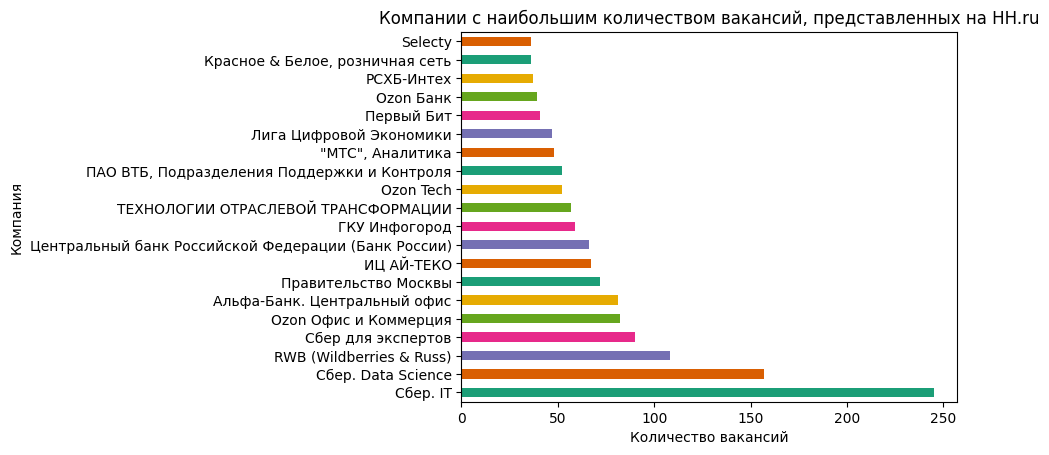

In [67]:
company_top1 = hh.groupby('company').size().sort_values(ascending=False).head(20)
company_top1.plot(kind='barh', color=sns.mpl_palette('Dark2'))
plt.title('Компании с наибольшим количеством вакансий, представленных на HH.ru')
plt.xlabel('Количество вакансий')
plt.ylabel('Компания')
plt.show()

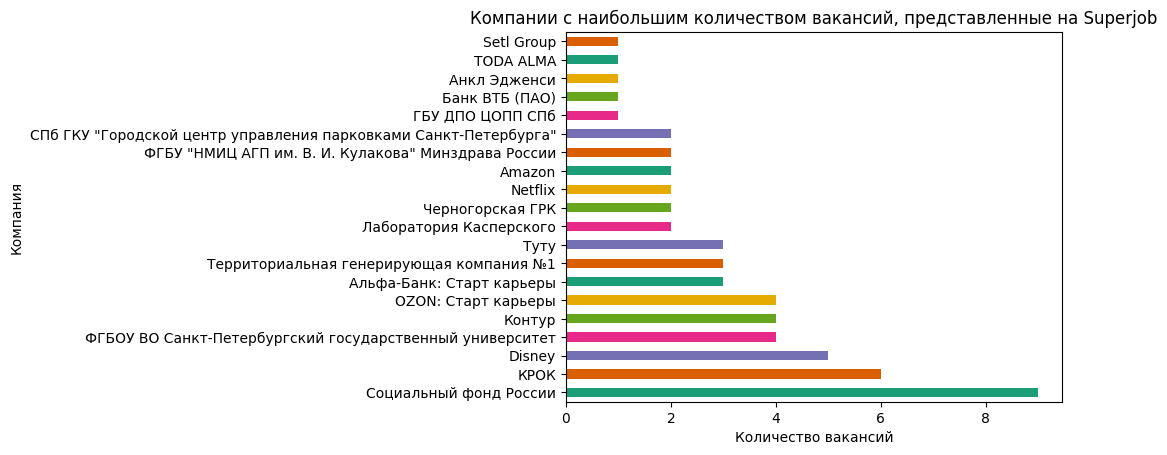

In [66]:
company_top2 = superjob.groupby('company').size().sort_values(ascending=False).head(20)
company_top2.plot(kind='barh', color=sns.mpl_palette('Dark2'))
plt.title('Компании с наибольшим количеством вакансий, представленные на Superjob')
plt.xlabel('Количество вакансий')
plt.ylabel('Компания')
plt.show()

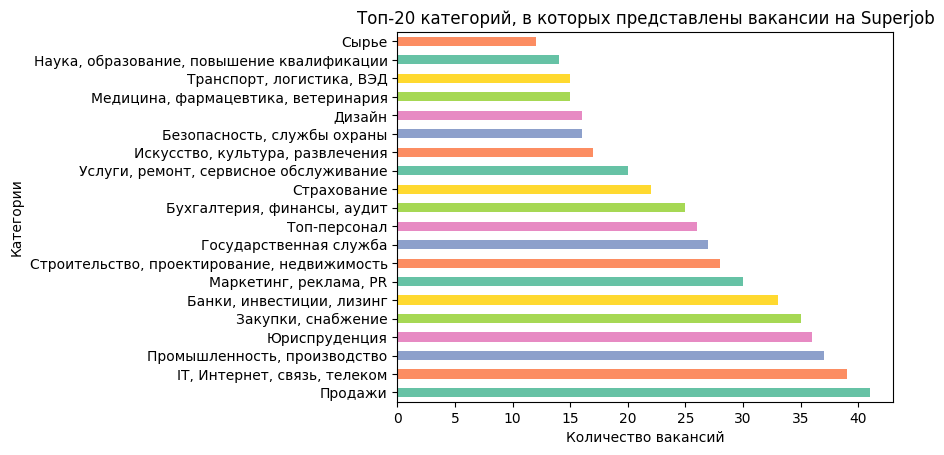

In [68]:
category_top = superjob_catalogues.groupby('catalogue_title').size().sort_values(ascending=False).head(20)

category_top.plot(kind='barh', color=sns.mpl_palette('Set2'))
plt.title('Топ-20 категорий, в которых представлены вакансии на Superjob')
plt.xlabel('Количество вакансий')
plt.ylabel('Категории')
plt.show()

# Ребята решили, что могут быть вопросы про палитру цветов, поэтому указываем источник: https://seaborn.pydata.org/generated/seaborn.mpl_palette.html

Можем заметить, что наибольшее число вакансий в компаниях, относящихся к следующим подгруппам - Бигтех и ИТ-компании.

Также отметим, что на SuperJob активно представлены компании, относящиеся к госструктурам и социальной сфере.

**Вывод:** Необходимо изучать рынок ИТ-вакансий и смежные с эти сферы, чтобы успешно пройти собеседование и трудоустроиться.

**2.2 На какой опыт расчитаны представленные вакансии?**

In [51]:
print(hh['experience'].unique())
print(superjob['experience'].unique())
print(hh['employment'].unique())
print('\n')

print(superjob['employment'].unique())

['не требуется' '1–3 года' '3–6 лет' 'более 6 лет' nan]
['Без опыта' 'От 3 лет' 'От 1 года' 'От 6 лет']
['Полная занятость Стажировка' 'Полная занятость'
 'Частичная занятость Стажировка' 'Проект или разовое задание'
 'Частичная занятость' nan 'Подработка' 'Подработка Стажировка'
 'Проект или разовое задание Стажировка']


['Полный рабочий день' 'Неполная дистанционная занятость'
 'Сменный график работы']


Приведем стаж к единому виду в обеих выборках для удобства анализа.

In [52]:
hh['experience'] = hh['experience'].replace({'не требуется': 'Без опыта', '1–3 года': 'От 1 года',
                                             '3–6 лет': 'От 3 лет', 'более 6 лет': 'От 6 лет', 'nan': 'Не указано'})

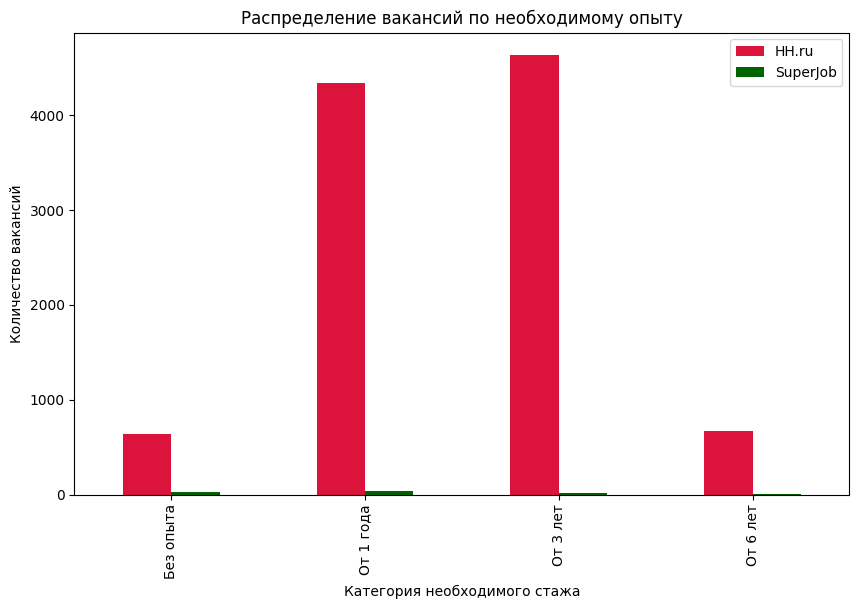

In [53]:
hh_exp = hh['experience'].value_counts()
superjob_exh = superjob['experience'].value_counts()


exp_new = pd.DataFrame({'HH.ru': hh_exp,'SuperJob': superjob_exh})
exp_new.plot(kind='bar', figsize=(10, 6), color=['Crimson', 'DarkGreen'])
plt.title('Распределение вакансий по необходимому опыту')
plt.xlabel('Категория необходимого стажа')
plt.ylabel('Количество вакансий')
plt.show()

**Вывод**: Вакансий для тех, чей опыт превышает 1 год, больше всего. Вакансий для стажеров и сеньоров - меньше всего.

Значит, для того, чтобы подобрать подходящую вакансию и повысить вероятность трудоустройства, необходим стаж, превыщающий 1 год.

**2.3 Какие специальности представлены?**

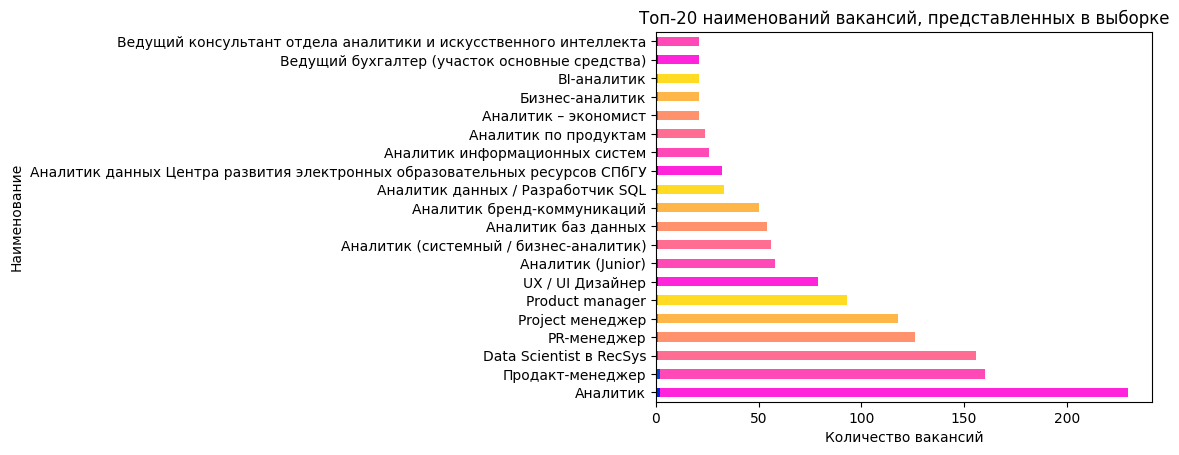

In [57]:
name_hh = hh.groupby('name').size().sort_values(ascending=False).head(20)
name_hh.plot(kind='barh', color=sns.palettes.mpl_palette('spring'))
name_superjob = superjob.groupby('name').size().sort_values(ascending=False).head(20)
name_superjob.plot(kind='barh', color=sns.palettes.mpl_palette('winter'))
plt.title('Топ-20 наименований вакансий, представленных в выборке')
plt.xlabel('Количество вакансий')
plt.ylabel('Наименование')
plt.show()

Следующие вакансии представлены в обеих выборках. Подавляющее большинство -  Аналитик, Продакт-менеджер, позиции, связанные с менеджментом и бизнес-системной аналитикой.

**Вывод**: вакансии есть в различных направлениях, но большинство - специальность Аналитик, объединяющая в себе многие другие. В различных компаниях названия одних и тех же вакансий могут сильно различаться (например Аналитик СПбГУ).

**2.4 Какие навыки необходимы для трудоустройства?**

Проанализируем перечень навыков, необходимых для трудоустройства, в различных компаниях.

/tmp/ipykernel_3695/385565138.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_skill_hh, y='skill', x='count', palette='autumn')


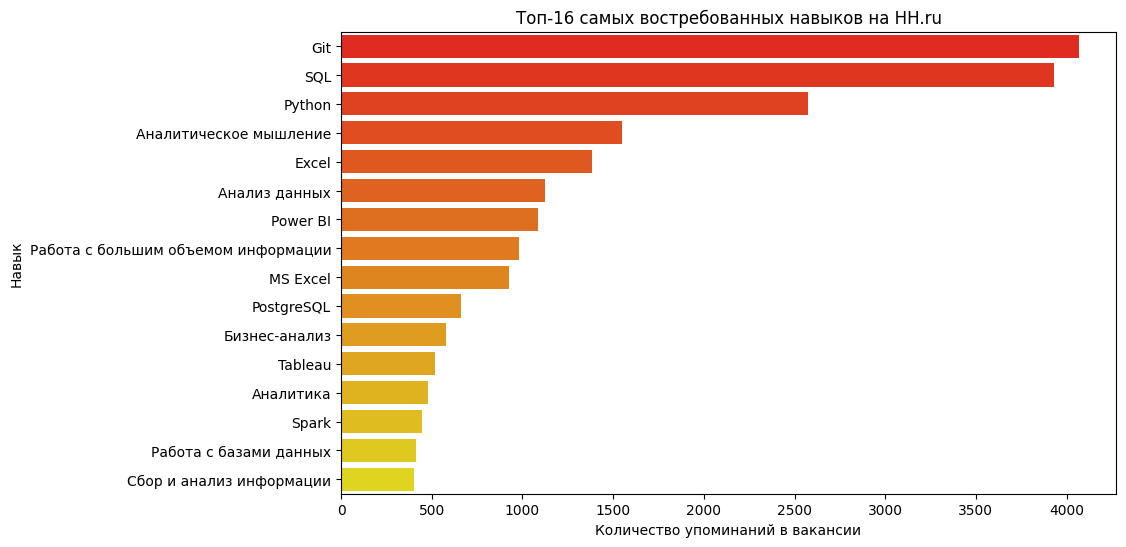

In [58]:
hh['skill'] = hh['skills'].apply(ast.literal_eval)
skill_list_hh = []
for i in hh['skill']:
    skill_list_hh.extend(i)
skill_count = Counter(skill_list_hh)
top_skill_hh = skill_count.most_common(16)
df_skill_hh = pd.DataFrame(top_skill_hh, columns=['skill', 'count'])

plt.figure(figsize=(10, 6))
sns.barplot(data=df_skill_hh, y='skill', x='count', palette='autumn')
plt.title('Топ-16 самых востребованных навыков на HH.ru')
plt.xlabel('Количество упоминаний в вакансии')
plt.ylabel('Навык')
plt.show()

Можем заметить, что Excel и MS Excel - это одно и то же. Объединим их для более качественного анализа платформы.

/tmp/ipykernel_3695/2757162145.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_skill_hh, y='skill', x='count', palette='autumn')


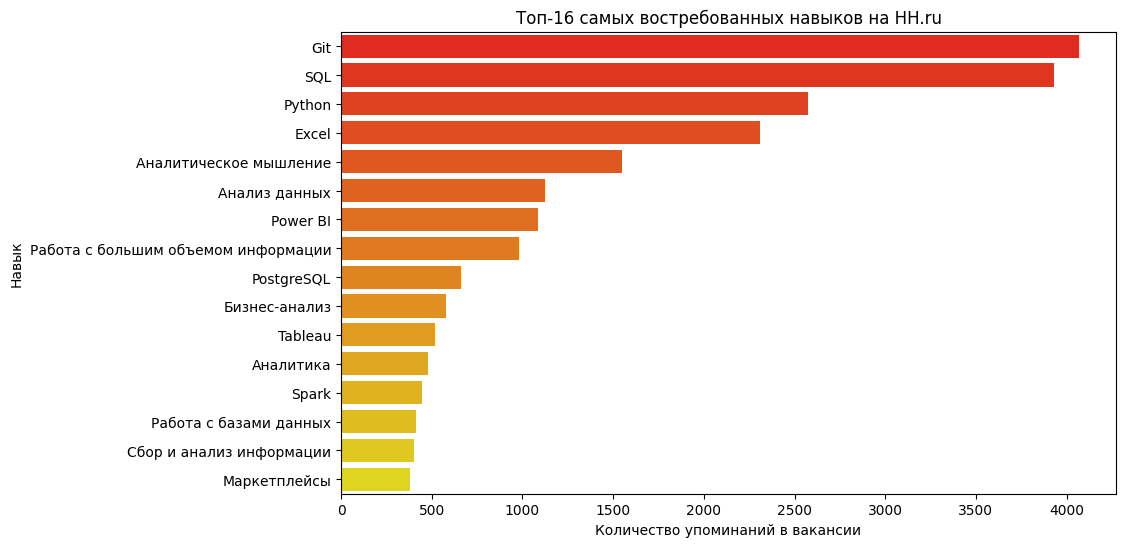

In [64]:
hh['skill'] = hh['skills'].apply(ast.literal_eval)
skill_list_hh = []
for i in hh['skill']:
    skill_list_hh.extend(i)
for i in range(len(skill_list_hh)):
    if skill_list_hh[i] == 'MS Excel':
      skill_list_hh[i] = 'Excel'
skill_count = Counter(skill_list_hh)
top_skill_hh = skill_count.most_common(16)
df_skill_hh = pd.DataFrame(top_skill_hh, columns=['skill', 'count'])
plt.figure(figsize=(10, 6))
sns.barplot(data=df_skill_hh, y='skill', x='count', palette='autumn')
plt.title('Топ-16 самых востребованных навыков на HH.ru')
plt.xlabel('Количество упоминаний в вакансии')
plt.ylabel('Навык')
plt.show()

Excel вышел на 4 место среди требуемых навыков для вакансий, связанных с аналитикой.

/tmp/ipykernel_3695/664623300.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_skill_superjob, y='skill', x='count', palette='summer')


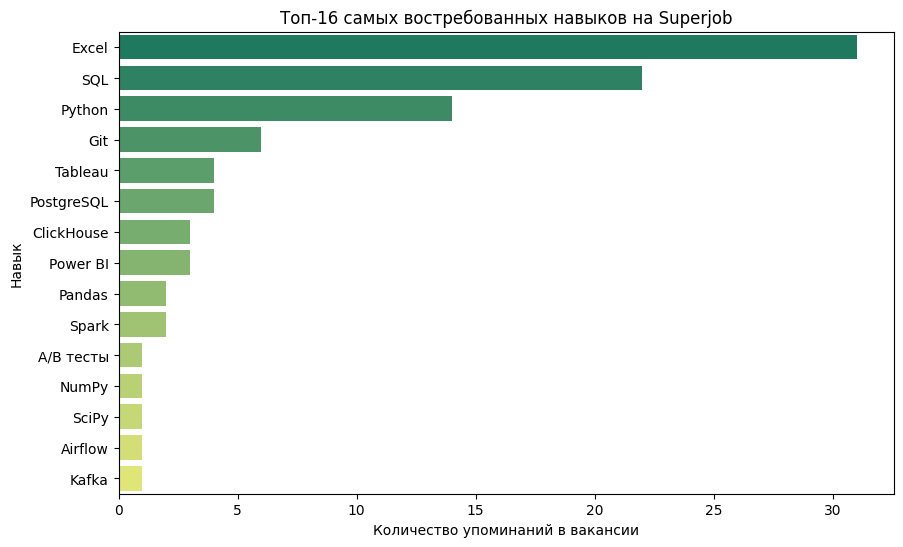

In [ ]:
superjob['skill'] = superjob['skills'].apply(ast.literal_eval)
skill_list_hh_super = []
for j in superjob['skill']:
    skill_list_hh_super.extend(j)
superjob_count = Counter(skill_list_hh_super)
top_skill_superjob = superjob_count.most_common(15)
df_skill_superjob = pd.DataFrame(top_skill_superjob, columns=['skill', 'count'])

plt.figure(figsize=(10, 6))
sns.barplot(data=df_skill_superjob, y='skill', x='count', palette='summer')
plt.title('Топ-16 самых востребованных навыков на Superjob')
plt.xlabel('Количество упоминаний в вакансии')
plt.ylabel('Навык')
plt.show()

Можем заметить, что на обеих платформах приоритет отдается навыкам, связанным с анализом данных, программированием и построением визуализаций данных, таким как Excel, Python, Sql, PostgreSQL и дргуим.

На платформе HH.ru большое внимание уделяется навыкам работы с Git, что является незаменимым инструментом при работе над командным проектом. Для Superjob Git является менее приоритетным в связи со спецификой вакансий (госсектор и гос компании).

**Вывод**: для того, чтобы успешно трудоустроиться, необходимо обладать навыками в областях, связанных с ИТ, менеджментом и аналитическим мышлением.

**2.5 Какой формат работы чаще всего необходим для принятия на работу?**

In [106]:
print(hh['employment'].unique())

['Полная занятость Стажировка' 'Полная занятость'
 'Частичная занятость Стажировка' 'Проект или разовое задание'
 'Частичная занятость' 'Не указано' 'Подработка' 'Подработка Стажировка'
 'Проект или разовое задание Стажировка']


Проанализируем, какая занятость сотрудников чаще всего требуется для трудоустройства.

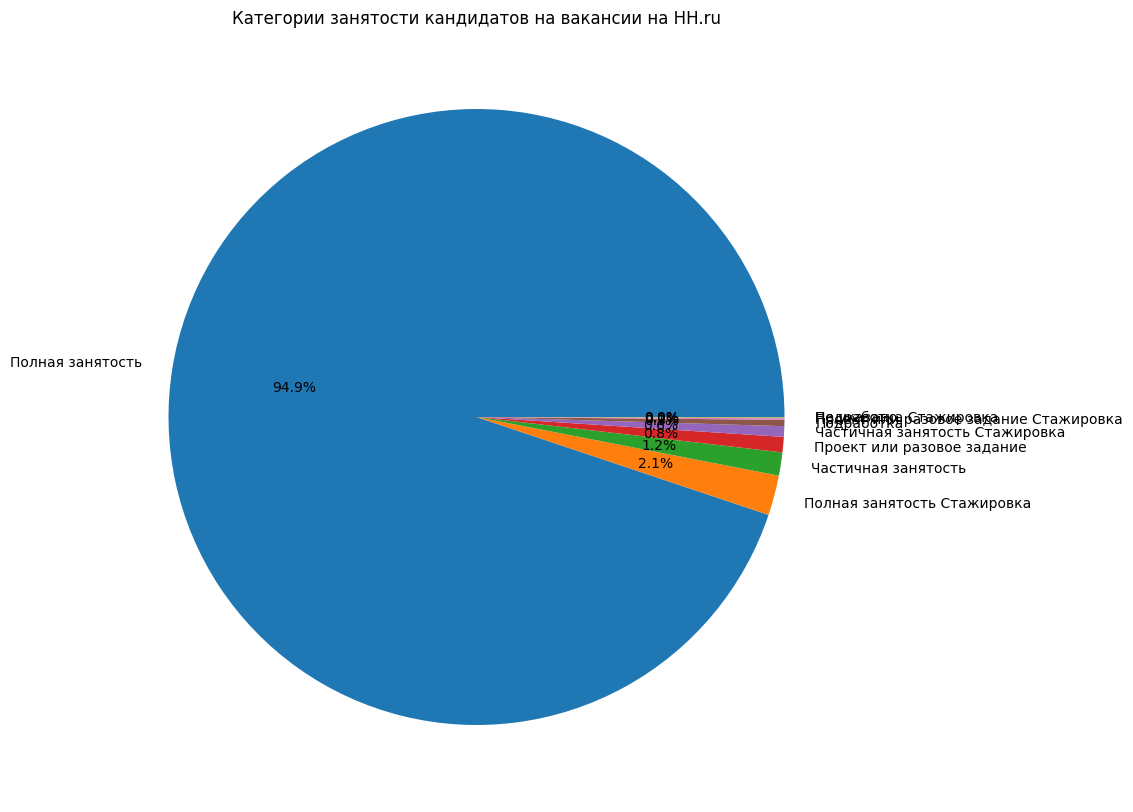

In [184]:
hh['employment'] = hh['employment'].fillna('Не указано')

hh_employment = hh['employment'].value_counts()
fig, ax = plt.subplots(figsize=(20, 10))
ax.pie(hh_employment.values, labels=hh_employment.index, autopct='%1.1f%%')
plt.title('Категории занятости кандидатов на вакансии на HH.ru')
plt.show()

Круговая диаграмма показывает, что почти все вакансии относятся к категории "Полная занятость".

Для более удобного представления, построим столбчатую диаграмму.

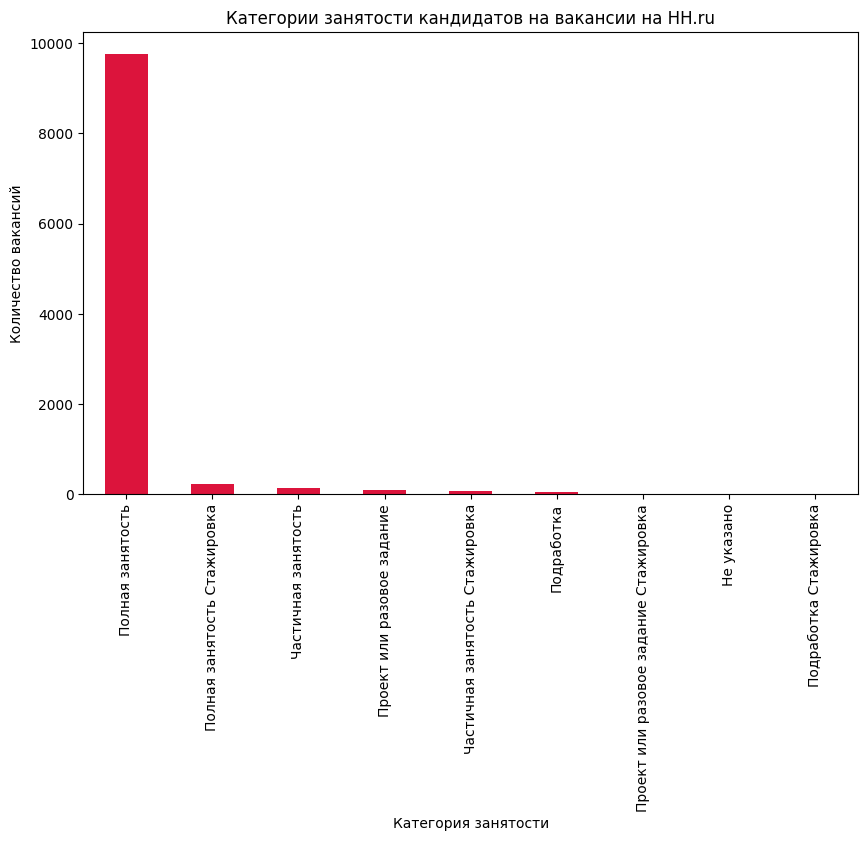

In [111]:
hh_employment.plot(kind='bar', figsize=(10, 6), color=['Crimson'])
plt.title('Категории занятости кандидатов на вакансии на HH.ru')
plt.xlabel('Категория занятости')
plt.ylabel('Количество вакансий')
plt.show()

Можем заметить, что большая часть вакансий относится к категории "Полная занятость", следующая по популярности категория "Полная занятость Стажировка".

Можем сделать **вывод**, что для того, чтобы получить работу и найти наиболее подходящую вакансию необходимо быть готовым работать полный рабочий день (40 часов), ежедневно.

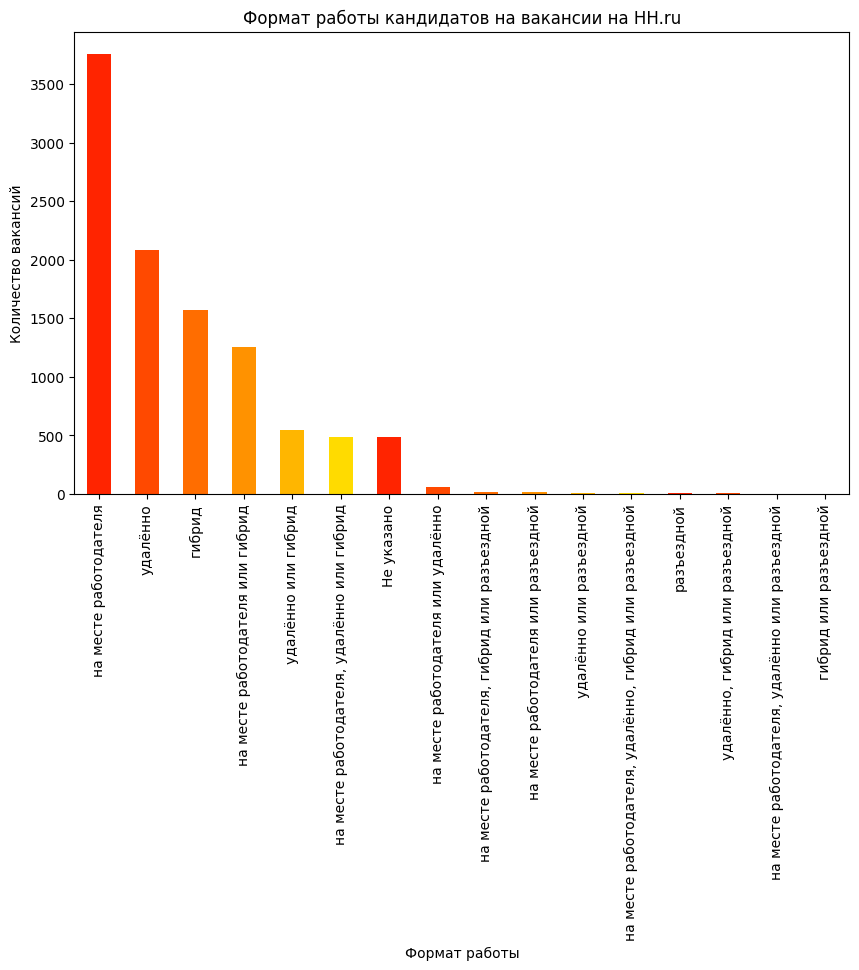

In [117]:
hh['work_format'] = hh['work_format'].fillna('Не указано')
hh_work_format = hh['work_format'].value_counts()
hh_work_format.plot(kind='bar', figsize=(10, 6), color=sns.mpl_palette('autumn'))
plt.title('Формат работы кандидатов на вакансии на HH.ru')
plt.xlabel('Формат работы')
plt.ylabel('Количество вакансий')
plt.show()

Большинство вакансий представлены в категориях "На месте работодателя", "Удаленно" и "Гибрид" (таких вакансий большинство). Более необычные форматы, включающие командировки или смешанные форматы являются скорее исключением из правил

**Вывод:** Для того, чтобы скорее найти работу, сотрудник преимущественно должен работать очно, на месте работодателя. Прмерно в два раза реже рассматриваются сотрудники, готовые работать только удаленно или совмещать работу в офисе и удаленно. В остальных случаях требование о формате работы скорее всего относится к специфике компании.

**2.6 Нужно ли образование для вакансии?**

Проанализируем, какая ступень образования необходима для того, чтобы претендовать на вакансию.

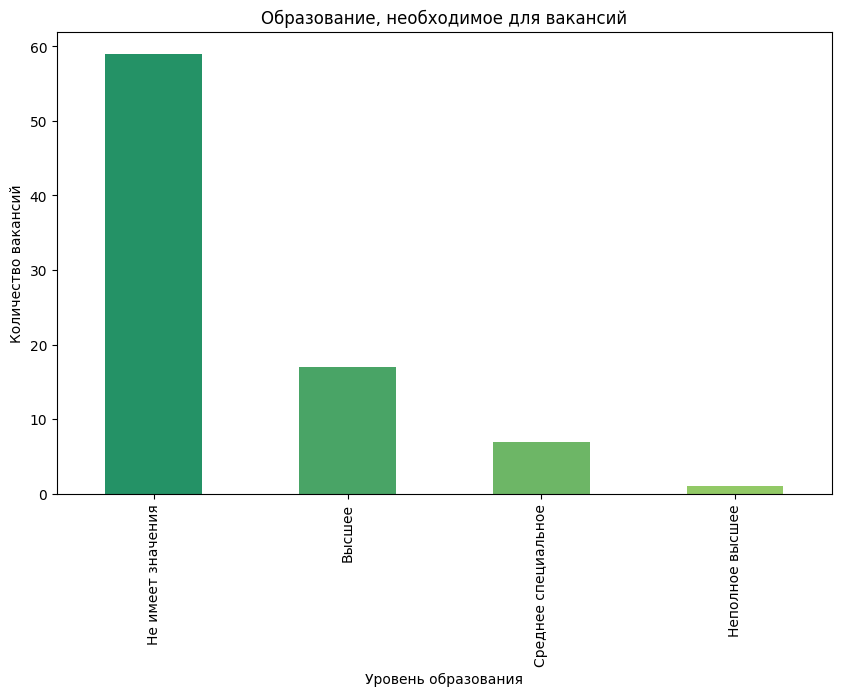

In [188]:
superjob_details['education'] = superjob_details['education'].fillna('Не указано')
superjob_details_education = superjob_details['education'].value_counts()
superjob_details_education.plot(kind='bar', figsize=(10, 6), color=sns.mpl_palette('summer'))
plt.title('Образование, необходимое для вакансий')
plt.xlabel('Уровень образования')
plt.ylabel('Количество вакансий')
plt.show()

**Вывод**: для большинства вакансий необходимый уровень образования не указан на платформе, однако можем заметить, что для другого большинства необходимо либо высшее образование, либо колледж (среднее специальное), то есть то образование, где получают профессию.